In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
df = pd.read_csv("spam.csv", encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
print(df.shape)
print(df.info())
print(df.describe())

(5572, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB
None
          v1                      v2  \
count   5572                    5572   
unique     2                    5169   
top      ham  Sorry, I'll call later   
freq    4825                      30   

                                               Unnamed: 2  \
count                                                  50   
unique                                                 43   
top      bt not his girlfrnd... G o o d n i g h t . . .@"   
freq                                                    3   

                   Unnamed: 3 Unnamed: 4  
count  

In [5]:
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

In [6]:
print(df.isnull().sum())

df.dropna(inplace=True)

label      0
message    0
dtype: int64


In [7]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

Duplicate Rows: 403


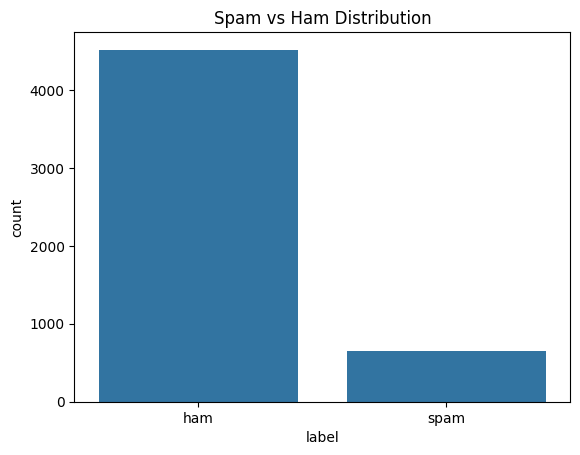

In [8]:
sns.countplot(x='label', data=df)
plt.title("Spam vs Ham Distribution")
plt.savefig("class_distribution.png")
plt.show()

In [9]:
df['message_length'] = df['message'].apply(len)

df.head()

,label,message,message_length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


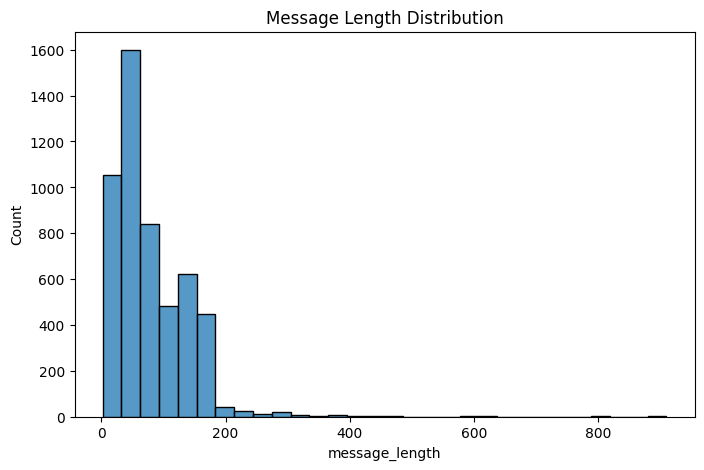

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['message_length'], bins=30)
plt.title("Message Length Distribution")
plt.savefig("message_length_distribution.png")
plt.show()

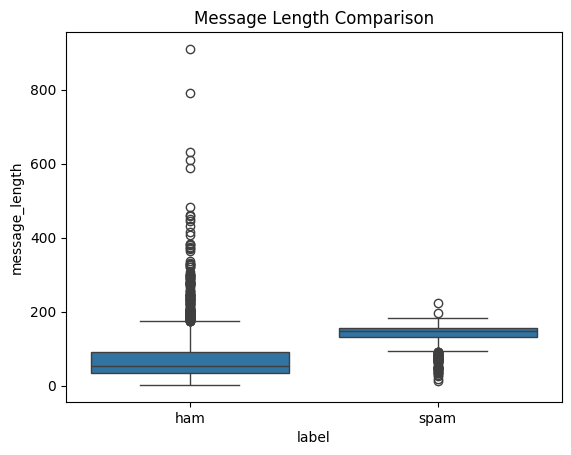

In [11]:
sns.boxplot(x='label', y='message_length', data=df)
plt.title("Message Length Comparison")
plt.savefig("length_comparison.png")
plt.show()

In [12]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

In [13]:
vectorizer = TfidfVectorizer(stop_words='english')

X = vectorizer.fit_transform(df['message'])
y = df['label']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

In [18]:
y_pred = model.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.965183752417795


In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       889
           1       1.00      0.75      0.86       145

    accuracy                           0.97      1034
   macro avg       0.98      0.88      0.92      1034
weighted avg       0.97      0.97      0.96      1034



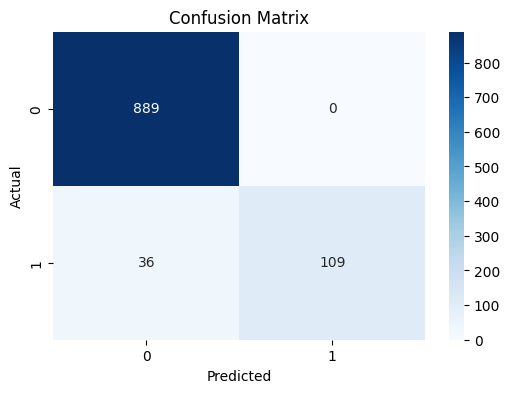

In [21]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")
plt.show()

In [22]:
sample = [
    "Congratulations! You won a free iPhone. Claim now!"
]

sample_vector = vectorizer.transform(sample)

prediction = model.predict(sample_vector)

if prediction[0] == 1:
    print("Spam Message")
else:
    print("Not Spam Message")

Spam Message
